# CQT info — flow-2

Inspect cached CQT features for a single dataset: shape, example spectrograms, per-class grids.

**Artifacts**
- Audio: `datasets/flow-2/{class}/*`
- Features: `features/flow-2.npz` (run `cqt-extraction.ipynb` if missing)

Sibling notebooks: `notebooks/training/cqt-info.ipynb`, `notebooks/vivo/cqt-info.ipynb`.


In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa

EXPERIMENT_RANDOM_STATE = 42
random.seed(EXPERIMENT_RANDOM_STATE)
np.random.seed(EXPERIMENT_RANDOM_STATE)

# --- per-dataset config (this notebook is under notebooks/flow-2/) ---
DATASET = "flow-2"
FEATURES_NAME = "flow-2.npz"  # vivo/flow-2: "{DATASET}.npz"

root_dir = "../../"
dataset_dir = os.path.join(root_dir, "datasets", DATASET)
features_path = os.path.join(root_dir, "features", FEATURES_NAME)

fmin = librosa.note_to_hz("C1")
hop_length = 512
bins_per_octave = 36
sr_default = 48_000

print({
    "dataset": DATASET,
    "dataset_dir": dataset_dir,
    "features_path": features_path,
})


{'dataset': 'flow-2', 'dataset_dir': '../../datasets/flow-2', 'features_path': '../../features/flow-2.npz'}


# Read Features

In [2]:
if os.path.exists(features_path):
    data = np.load(features_path)
    exp_features = np.asarray(data["features"])
    exp_labels = np.asarray(data["labels"])
else:
    raise FileNotFoundError(
        f"Expected features file was not found: {features_path}\n"
        f"Run notebooks/{DATASET}/cqt-extraction.ipynb first."
    )

max_cqt_pad_len = exp_features.shape[2] if exp_features.ndim == 3 else 200

print(f"Loaded features: {exp_features.shape}")
print(f"Loaded labels:   {exp_labels.shape}")
print(f"Unique classes:  {len(np.unique(exp_labels))}")

Loaded features: (1440, 216, 188)
Loaded labels:   (1440,)
Unique classes:  36


# 1. Visualize What Is Inside A CQT Frame

Sample index: 128
Label: A_diminished_4
CQT shape (bins x frames): (216, 188)


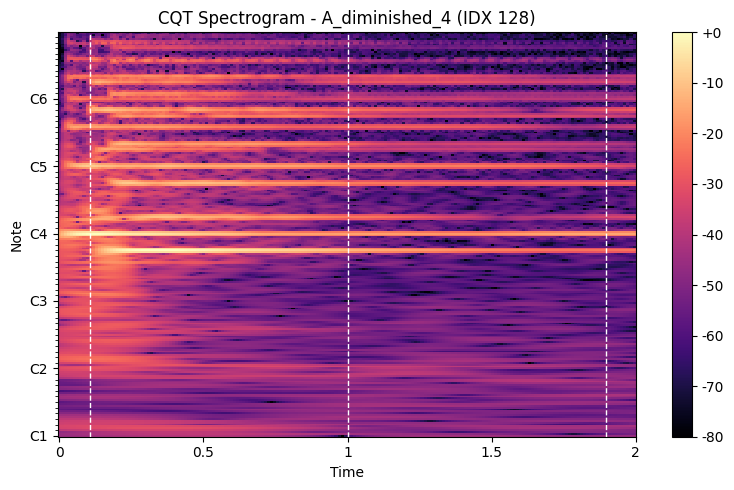

In [3]:
rng = np.random.default_rng(EXPERIMENT_RANDOM_STATE)
import librosa.display

sample_idx = int(rng.integers(0, len(exp_features)))
sample_cqt = exp_features[sample_idx]
sample_label = exp_labels[sample_idx]

bins_per_note = bins_per_octave // 12
n_notes = int(np.ceil(sample_cqt.shape[0] / bins_per_note))

start_midi = librosa.note_to_midi("C1")
note_names = np.repeat(
    [librosa.midi_to_note(m, octave=True) for m in range(start_midi, start_midi + n_notes)],
    bins_per_note
)[:sample_cqt.shape[0]]

n_frames = sample_cqt.shape[1]
time_axis = np.arange(n_frames) * hop_length / sr_default

frame_a = min(10, n_frames - 1)
frame_b = n_frames // 2
frame_c = max(n_frames - 10, 0)
frame_points = [frame_a, frame_b, frame_c]

print(f'Sample index: {sample_idx}')
print(f'Label: {sample_label}')
print(f'CQT shape (bins x frames): {sample_cqt.shape}')

plt.figure(figsize=(8, 5))
librosa.display.specshow(
    sample_cqt,
    x_axis='time',
    y_axis='cqt_note',
    sr=sr_default,
    fmin=fmin,
    bins_per_octave=bins_per_octave,
    hop_length=hop_length,
)
for fp in frame_points:
    plt.axvline(fp * hop_length / sr_default, color='white', linestyle='--', linewidth=1)
plt.title(f'CQT Spectrogram - {sample_label} (IDX {sample_idx})')
plt.colorbar(format='%+2.0f')
plt.tight_layout()
plt.show()

### 1.1 Frame-Level Note Energy At Selected Time Steps

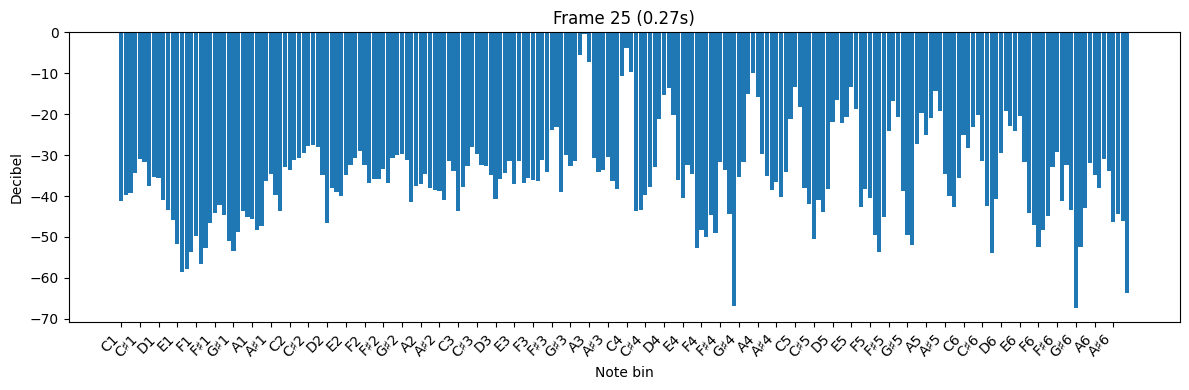

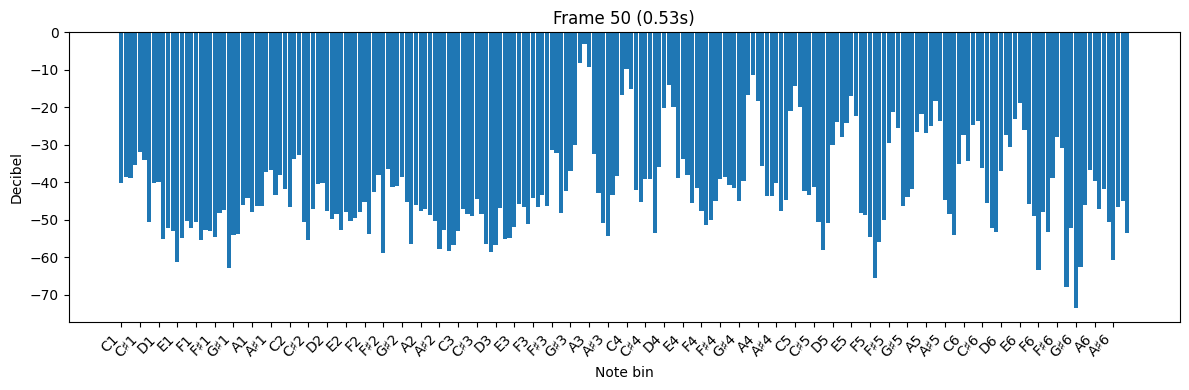

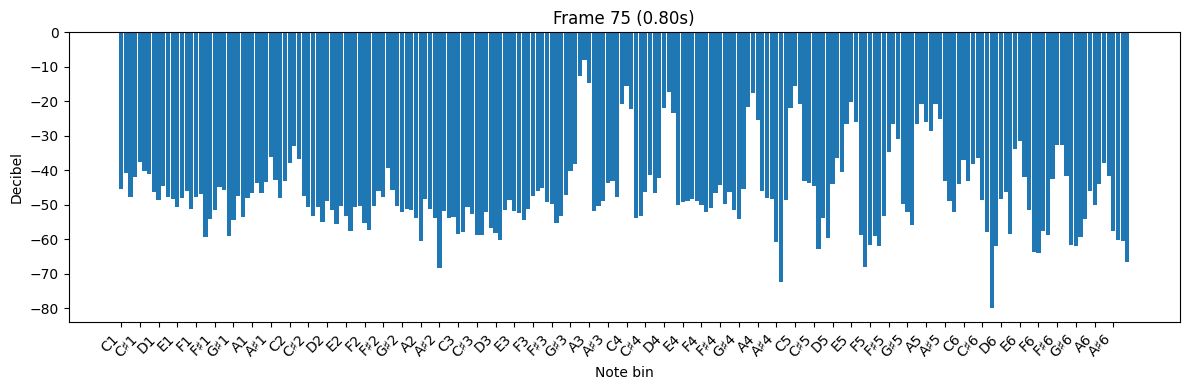

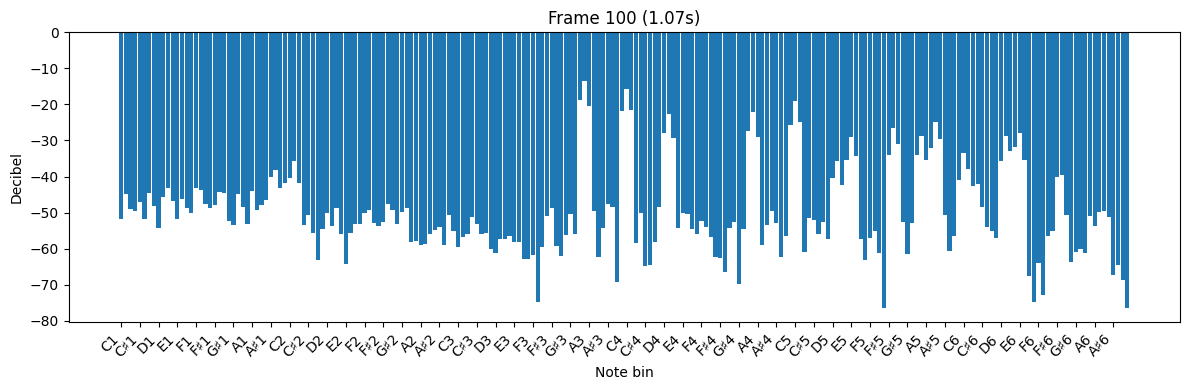

In [4]:
frame_points = [25, 50, 75, 100]
if sample_cqt.shape[1] <= max(frame_points):
    raise ValueError(f'Need at least {max(frame_points) + 1} frames, got {sample_cqt.shape[1]}')

for fp in frame_points:
    plt.figure(figsize=(12, 4))
    plt.bar(np.arange(len(note_names)), sample_cqt[:, fp], width=0.9)
    plt.title(f'Frame {fp} ({fp * hop_length / sr_default:.2f}s)')
    plt.xlabel('Note bin')
    plt.ylabel('Decibel')
    plt.xticks(np.arange(len(note_names))[::4], note_names[::4], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 1.2 3D CQT Surface View

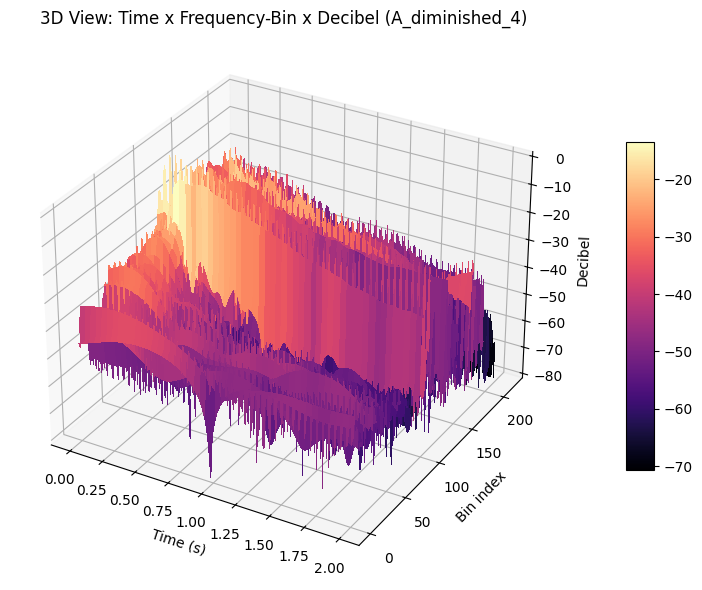

In [5]:
X, Y = np.meshgrid(time_axis, np.arange(sample_cqt.shape[0]))
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, sample_cqt, cmap='magma', linewidth=0, antialiased=False)
ax.set_title(f'3D View: Time x Frequency-Bin x Decibel ({sample_label})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Bin index')
ax.set_zlabel('Decibel')
fig.colorbar(surf, shrink=0.6, aspect=12)
plt.tight_layout()
plt.show()

### 1.3 Data Frame Table

In [6]:
sample_df = pd.DataFrame(
    sample_cqt,
    index=note_names,
    columns=[f'frame_{i}' for i in range(sample_cqt.shape[1])],
    dtype=float,
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
  display(sample_df)

,frame_0,frame_1,frame_2,frame_3,frame_4,frame_5,frame_6,frame_7,frame_8,frame_9,frame_10,frame_11,frame_12,frame_13,frame_14,frame_15,frame_16,frame_17,frame_18,frame_19,frame_20,frame_21,frame_22,frame_23,frame_24,frame_25,frame_26,frame_27,frame_28,frame_29,frame_30,frame_31,frame_32,frame_33,frame_34,frame_35,frame_36,frame_37,frame_38,frame_39,frame_40,frame_41,frame_42,frame_43,frame_44,frame_45,frame_46,frame_47,frame_48,frame_49,frame_50,frame_51,frame_52,frame_53,frame_54,frame_55,frame_56,frame_57,frame_58,frame_59,frame_60,frame_61,frame_62,frame_63,frame_64,frame_65,frame_66,frame_67,frame_68,frame_69,frame_70,frame_71,frame_72,frame_73,frame_74,frame_75,frame_76,frame_77,frame_78,frame_79,frame_80,frame_81,frame_82,frame_83,frame_84,frame_85,frame_86,frame_87,frame_88,frame_89,frame_90,frame_91,frame_92,frame_93,frame_94,frame_95,frame_96,frame_97,frame_98,frame_99,frame_100,frame_101,frame_102,frame_103,frame_104,frame_105,frame_106,frame_107,frame_108,frame_109,frame_110,frame_111,frame_112,frame_113,frame_114,frame_115,frame_116,frame_117,frame_118,frame_119,frame_120,frame_121,frame_122,frame_123,frame_124,frame_125,frame_126,frame_127,frame_128,frame_129,frame_130,frame_131,frame_132,frame_133,frame_134,frame_135,frame_136,frame_137,frame_138,frame_139,frame_140,frame_141,frame_142,frame_143,frame_144,frame_145,frame_146,frame_147,frame_148,frame_149,frame_150,frame_151,frame_152,frame_153,frame_154,frame_155,frame_156,frame_157,frame_158,frame_159,frame_160,frame_161,frame_162,frame_163,frame_164,frame_165,frame_166,frame_167,frame_168,frame_169,frame_170,frame_171,frame_172,frame_173,frame_174,frame_175,frame_176,frame_177,frame_178,frame_179,frame_180,frame_181,frame_182,frame_183,frame_184,frame_185,frame_186,frame_187
C1,-45.925243,-45.729652,-45.534908,-45.340881,-45.146759,-44.952652,-44.758144,-44.563141,-44.367882,-44.172306,-43.976128,-43.780479,-43.585358,-43.390968,-43.198341,-43.007324,-42.818439,-42.632507,-42.449703,-42.270996,-42.096889,-41.927135,-41.762428,-41.603661,-41.450733,-41.303936,-41.163651,-41.030491,-40.904232,-40.785023,-40.673435,-40.569515,-40.472816,-40.383770,-40.302631,-40.229385,-40.164043,-40.106361,-40.056477,-40.014668,-39.980576,-39.954643,-39.936874,-39.927174,-39.925236,-39.931362,-39.945641,-39.968254,-39.999344,-40.038666,-40.086964,-40.143738,-40.209503,-40.284710,-40.369465,-40.463837,-40.568199,-40.683586,-40.810040,-40.947865,-41.097717,-41.260098,-41.435555,-41.624931,-41.828732,-42.047668,-42.283070,-42.535427,-42.805935,-43.096352,-43.408192,-43.742069,-44.100513,-44.485085,-44.899033,-45.344807,-45.825382,-46.345322,-46.909637,-47.524399,-48.195629,-48.934475,-49.752148,-50.663696,-51.692947,-52.869095,-54.238953,-55.870850,-57.886543,-60.513809,-64.286385,-70.993149,-80.000000,-68.155502,-62.917812,-59.688652,-57.359653,-55.547741,-54.073891,-52.836567,-51.774445,-50.850338,-50.036503,-49.313774,-48.668419,-48.089417,-47.568100,-47.097572,-46.672218,-46.287430,-45.939350,-45.624710,-45.340725,-45.084953,-44.855282,-44.649822,-44.466904,-44.305008,-44.162758,-44.038898,-43.932278,-43.841824,-43.766537,-43.705490,-43.657818,-43.622704,-43.599392,-43.587162,-43.585350,-43.593254,-43.610714,-43.636734,-43.670807,-43.710636,-43.760075,-43.812447,-43.873367,-43.940041,-44.010918,-44.089535,-44.171764,-44.260937,-44.354477,-44.455627,-44.560608,-44.669514,-44.785236,-44.902287,-45.025246,-45.148041,-45.273067,-45.401161,-45.526402,-45.653824,-45.778900,-45.900501,-46.019608,-46.134792,-46.244389,-46.348560,-46.445923,-46.536934,-46.618484,-46.691902,-46.756390,-46.811211,-46.855927,-46.890526,-46.914597,-46.929035,-46.933506,-46.928032,-46.913574,-46.890079,-46.858852,-46.820374,-46.774529,-46.723316,-46.667862,-46.606457,-46.541790,-46.473892,-46.402973,-46.329399,-46.253609,-46.177483,-46.099575,-46.020836
C1,-45.967602,-45.595959,-45.237354,-44.887554,-44.552227,-44.226845,-43.914558,-43.610828,-43.316071,-43.033577,-42.762264,-42.496552,-42.241756,-41.995903,-

# 2. Group Visualization

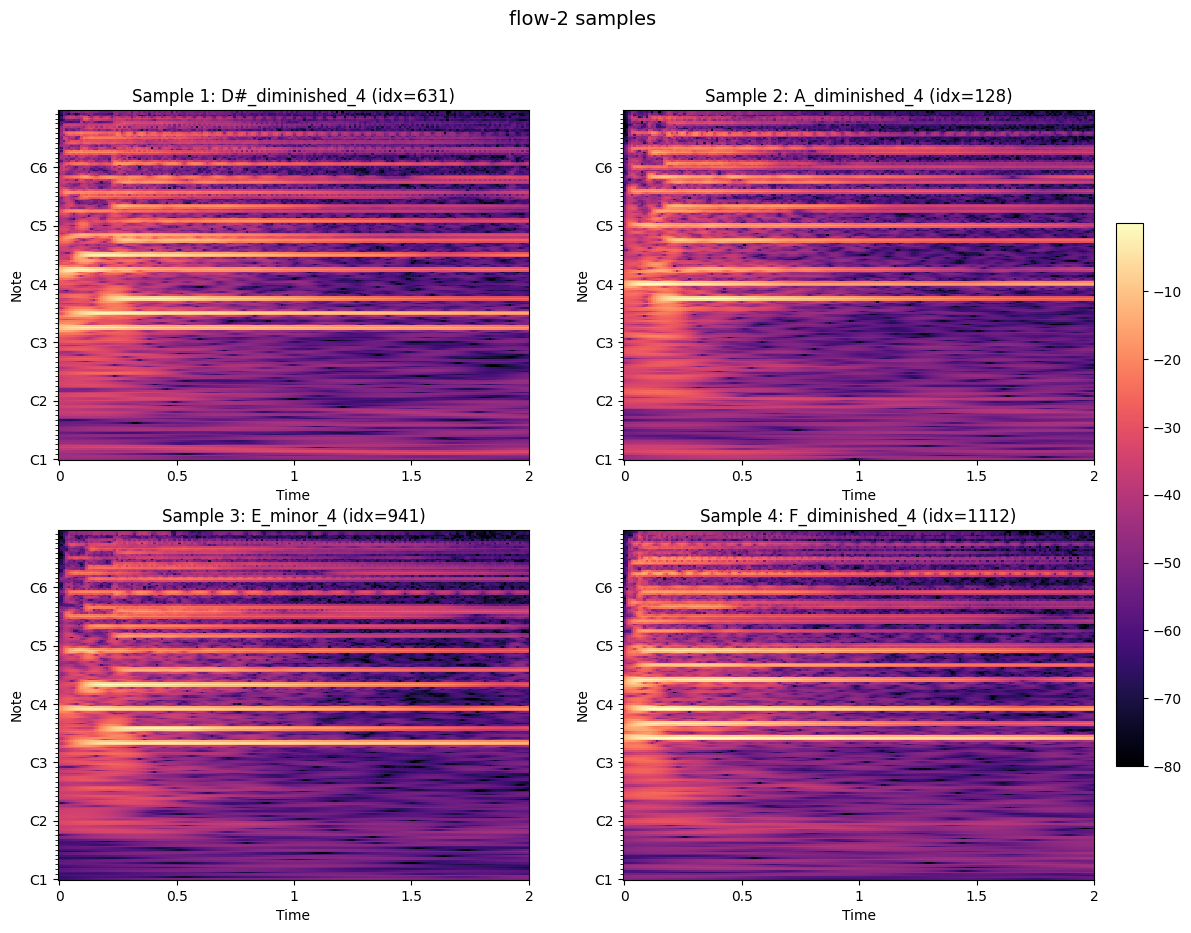

In [7]:
rng_group = np.random.default_rng(EXPERIMENT_RANDOM_STATE)

def plot_random_cqt_grid(features, labels, title, n_samples=4):
    if features.ndim != 3:
        raise RuntimeError(f'Expected features with shape (N, bins, frames), got {features.shape}')

    n_show = min(n_samples, len(features))
    if n_show == 0:
        raise RuntimeError(f'No samples available for {title.lower()}')

    sample_indices = rng_group.choice(len(features), size=n_show, replace=False)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), squeeze=False)
    axes_flat = axes.flatten()

    # vmin = float(np.percentile(features[sample_indices], 2))
    # vmax = float(np.percentile(features[sample_indices], 98))
    last_im = None

    for sample_number, (ax, sample_idx) in enumerate(zip(axes_flat, sample_indices), start=1):
        sample_cqt = features[sample_idx]
        sample_label = labels[sample_idx]
        last_im = librosa.display.specshow(
            sample_cqt,
            ax=ax,
            x_axis='time',
            y_axis='cqt_note',
            sr=sr_default,
            fmin=fmin,
            bins_per_octave=bins_per_octave,
            hop_length=hop_length,
            cmap='magma',
            # vmin=vmin,
            # vmax=vmax,
        )
        ax.set_title(f'Sample {sample_number}: {sample_label} (idx={int(sample_idx)})')
        ax.set_xlabel('Time')
        ax.set_ylabel('Note')

    for ax in axes_flat[n_show:]:
        ax.axis('off')

    fig.suptitle(title, fontsize=14, y=0.98)
    fig.colorbar(last_im, ax=axes, fraction=0.025, pad=0.02)
    plt.show()

plot_random_cqt_grid(
    exp_features,
    exp_labels,
    f'{DATASET} samples',
)

# Cross-dataset / train-vs-eval comparison

This notebook is **single-dataset only**. Former train-vs-eval and noise-bias sections were removed so each of `training` / `vivo` / `flow-2` can be analyzed independently.

For device comparison, open the sibling `cqt-info.ipynb` under each dataset folder (after running that folder’s `cqt-extraction.ipynb`).